<a href="https://colab.research.google.com/github/dahouda2pro/Projects_Science_2_Donnees/blob/main/projet_multidiciplinaire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow import keras
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import re
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
%matplotlib inline
#definition d'une taille de figure universelle
rcParams['figure.figsize'] = 8, 6

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**importation du fichier**

recherche du fichier sur colab avec os

In [ ]:
os.listdir()

['.config', 'student_prediction.csv', 'drive', 'sample_data']

In [ ]:
%cd /content/projet multidisciplinaire

[Errno 2] No such file or directory: '/content/projet multidisciplinaire'
/content


infectation du fichier dans un variable pour la lecture du fichier

In [ ]:
data = open('student_prediction.csv', 'r').read()

In [ ]:
data=('student_prediction.csv')

coversiontion du fichier en data set

In [ ]:
Data= pd.read_csv(data)
Data.head(20)

,STUDENTID,AGE,GENDER,HS_TYPE,SCHOLARSHIP,WORK,ACTIVITY,PARTNER,SALARY,TRANSPORT,...,PREP_STUDY,PREP_EXAM,NOTES,LISTENS,LIKES_DISCUSS,CLASSROOM,CUML_GPA,EXP_GPA,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,...,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,...,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,...,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,...,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,...,2,1,2,2,2,1,2,2,1,1
5,STUDENT6,2,2,2,3,2,2,2,2,1,...,1,1,1,2,1,2,4,4,1,2
6,STUDENT7,1,2,2,4,2,2,2,1,1,...,1,1,3,3,3,3,4,4,1,5
7,STUDENT8,1,1,2,3,1,1,1,2,2,...,3,1,3,2,2,1,1,1,1,2
8,STUDENT9,2,1,3,3,2,1,1,1,1,...,1,1,3,2,2,2,4,3,1,5
9,STUDENT10,2,1,2,3,2,2,1,3,4,...,1,1,2,2,2,2,1,2,1,0


In [ ]:

Data['GRADE'].unique()

array([1, 2, 5, 0, 3, 4, 7, 6])

In [ ]:
Data.shape

(145, 33)

In [ ]:
Data.columns

Index(['STUDENTID', 'AGE', 'GENDER', 'HS_TYPE', 'SCHOLARSHIP', 'WORK',
       'ACTIVITY', 'PARTNER', 'SALARY', 'TRANSPORT', 'LIVING', 'MOTHER_EDU',
       'FATHER_EDU', '#_SIBLINGS', 'KIDS', 'MOTHER_JOB', 'FATHER_JOB',
       'STUDY_HRS', 'READ_FREQ', 'READ_FREQ_SCI', 'ATTEND_DEPT', 'IMPACT',
       'ATTEND', 'PREP_STUDY', 'PREP_EXAM', 'NOTES', 'LISTENS',
       'LIKES_DISCUSS', 'CLASSROOM', 'CUML_GPA', 'EXP_GPA', 'COURSE ID',
       'GRADE'],
      dtype='object')

In [ ]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 33 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   STUDENTID      145 non-null    object
 1   AGE            145 non-null    int64 
 2   GENDER         145 non-null    int64 
 3   HS_TYPE        145 non-null    int64 
 4   SCHOLARSHIP    145 non-null    int64 
 5   WORK           145 non-null    int64 
 6   ACTIVITY       145 non-null    int64 
 7   PARTNER        145 non-null    int64 
 8   SALARY         145 non-null    int64 
 9   TRANSPORT      145 non-null    int64 
 10  LIVING         145 non-null    int64 
 11  MOTHER_EDU     145 non-null    int64 
 12  FATHER_EDU     145 non-null    int64 
 13  #_SIBLINGS     145 non-null    int64 
 14  KIDS           145 non-null    int64 
 15  MOTHER_JOB     145 non-null    int64 
 16  FATHER_JOB     145 non-null    int64 
 17  STUDY_HRS      145 non-null    int64 
 18  READ_FREQ      145 non-null   

affichage des information sur le data

affichages des statistique descriptives

In [ ]:
Data.describe()

,AGE,GENDER,HS_TYPE,SCHOLARSHIP,WORK,ACTIVITY,PARTNER,SALARY,TRANSPORT,LIVING,...,PREP_STUDY,PREP_EXAM,NOTES,LISTENS,LIKES_DISCUSS,CLASSROOM,CUML_GPA,EXP_GPA,COURSE ID,GRADE
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,...,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000
mean,1.620690,1.600000,1.944828,3.572414,1.662069,1.600000,1.579310,1.627586,1.620690,1.731034,...,1.337931,1.165517,2.544828,2.055172,2.393103,1.806897,3.124138,2.724138,4.131034,3.227586
std,0.613154,0.491596,0.537216,0.805750,0.474644,0.491596,0.495381,1.020245,1.061112,0.783999,...,0.614870,0.408483,0.564940,0.674736,0.604343,0.810492,1.301083,0.916536,3.260145,2.197678
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,...,1.000000,1.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,1.000000,3.000000,3.000000,3.000000,2.000000,4.000000,3.000000,7.000000,5.000000
max,3.000000,2.000000,3.000000,5.000000,2.000000,2.000000,2.000000,5.000000,4.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,5.000000,4.000000,9.000000,7.000000


affichages des valeurs maquantes
a. nombre de valeur manquante par colonne

In [ ]:
Data.isnull().sum()

,0
STUDENTID,0
AGE,0
GENDER,0
HS_TYPE,0
SCHOLARSHIP,0
WORK,0
ACTIVITY,0
PARTNER,0
SALARY,0
TRANSPORT,0


b.affichages des lignes avec le valeur manquante

In [ ]:
Data.duplicated().sum()

0

In [ ]:
Data.isnull().any(axis=1)

,0
0,False
1,False
2,False
3,False
4,False
...,...
140,False
141,False
142,False
143,False


## **Normalisation des donnees**

selection de colonne a normaliser

In [ ]:
colum_to_normalize=['AGE','GENDER','HS_TYPE','SCHOLARSHIP','ACTIVITY','PARTNER','SALARY','TRANSPORT','LIVING','MOTHER_EDU','FATHER_EDU','#_SIBLINGS',
                    'KIDS','MOTHER_JOB','FATHER_JOB','STUDY_HRS','READ_FREQ','READ_FREQ_SCI','ATTEND_DEPT','ATTEND','PREP_STUDY','PREP_EXAM','NOTES','LISTENS',
                    'LIKES_DISCUSS','CLASSROOM','CUML_GPA','EXP_GPA']

In [ ]:
scaler=MinMaxScaler()

In [ ]:
Data[colum_to_normalize]=scaler.fit_transform(Data[colum_to_normalize])


In [ ]:
Data.head()

,STUDENTID,AGE,GENDER,HS_TYPE,SCHOLARSHIP,WORK,ACTIVITY,PARTNER,SALARY,TRANSPORT,...,PREP_STUDY,PREP_EXAM,NOTES,LISTENS,LIKES_DISCUSS,CLASSROOM,CUML_GPA,EXP_GPA,COURSE ID,GRADE
0,STUDENT1,0.5,1.0,1.0,0.5,1,1.0,1.0,0.00,0.0,...,0.0,0.0,1.0,0.5,0.0,0.5,0.00,0.000000,1,1
1,STUDENT2,0.5,1.0,1.0,0.5,1,1.0,1.0,0.00,0.0,...,0.0,0.0,1.0,0.5,1.0,0.5,0.25,0.666667,1,1
2,STUDENT3,0.5,1.0,0.5,0.5,2,1.0,1.0,0.25,1.0,...,0.0,0.0,0.5,0.5,0.0,0.0,0.25,0.333333,1,1
3,STUDENT4,0.0,0.0,0.0,0.5,1,1.0,0.0,0.25,0.0,...,0.0,0.5,1.0,0.5,0.5,0.0,0.50,0.333333,1,1
4,STUDENT5,0.5,1.0,0.0,0.5,2,1.0,0.0,0.50,0.0,...,0.5,0.0,0.5,0.5,0.5,0.0,0.25,0.333333,1,1


In [ ]:
#from matplotlib import pyplot as plt
#_df_2['HS_TYPE'].plot(kind='hist', bins=20, title='HS_TYPE')
#plt.gca().spines[['top', 'right',]].set_visible(False)

### L'analyse des données par la colonne Nom

In [ ]:
Data['STUDENTID'].head()

,STUDENTID
0,STUDENT1
1,STUDENT2
2,STUDENT3
3,STUDENT4
4,STUDENT5


In [ ]:
Data['STUDENTID'].unique()

array(['STUDENT1', 'STUDENT2', 'STUDENT3', 'STUDENT4', 'STUDENT5',
       'STUDENT6', 'STUDENT7', 'STUDENT8', 'STUDENT9', 'STUDENT10',
       'STUDENT11', 'STUDENT12', 'STUDENT13', 'STUDENT14', 'STUDENT15',
       'STUDENT16', 'STUDENT17', 'STUDENT18', 'STUDENT19', 'STUDENT20',
       'STUDENT21', 'STUDENT22', 'STUDENT23', 'STUDENT24', 'STUDENT25',
       'STUDENT26', 'STUDENT27', 'STUDENT28', 'STUDENT29', 'STUDENT30',
       'STUDENT31', 'STUDENT32', 'STUDENT33', 'STUDENT34', 'STUDENT35',
       'STUDENT36', 'STUDENT37', 'STUDENT38', 'STUDENT39', 'STUDENT40',
       'STUDENT41', 'STUDENT42', 'STUDENT43', 'STUDENT44', 'STUDENT45',
       'STUDENT46', 'STUDENT47', 'STUDENT48', 'STUDENT49', 'STUDENT50',
       'STUDENT51', 'STUDENT52', 'STUDENT53', 'STUDENT54', 'STUDENT55',
       'STUDENT56', 'STUDENT57', 'STUDENT58', 'STUDENT59', 'STUDENT60',
       'STUDENT61', 'STUDENT62', 'STUDENT63', 'STUDENT64', 'STUDENT65',
       'STUDENT66', 'STUDENT67', 'STUDENT68', 'STUDENT69', 'STUDENT70',
 

In [ ]:
print(Data.groupby("GRADE")["GRADE"].mean())

GRADE
0    0.0
1    1.0
2    2.0
3    3.0
4    4.0
5    5.0
6    6.0
7    7.0
Name: GRADE, dtype: float64


# Reduction des nombres de classe pour la bonne prediction

In [ ]:
Data['GRADE'].value_counts()

,count
GRADE,
1,35
2,24
3,21
5,17
7,17
6,13
4,10
0,8


In [ ]:
Data['GRADE'].unique()

array([1, 2, 5, 0, 3, 4, 7, 6])

In [ ]:
Data['GRADE'] = Data['GRADE'].map({
    0 : 0,
    1 : 0,
    2 : 0,
    3 : 0,
    4 : 1,
    5 : 1,
    6 : 2,
    7 : 2
})

In [ ]:
Data['GRADE'].unique()

array([0, 1, 2])

In [ ]:
Data['GRADE'].value_counts()

,count
GRADE,
0,88
2,30
1,27


Nombre d'etudiant avoir la grade AA: 27


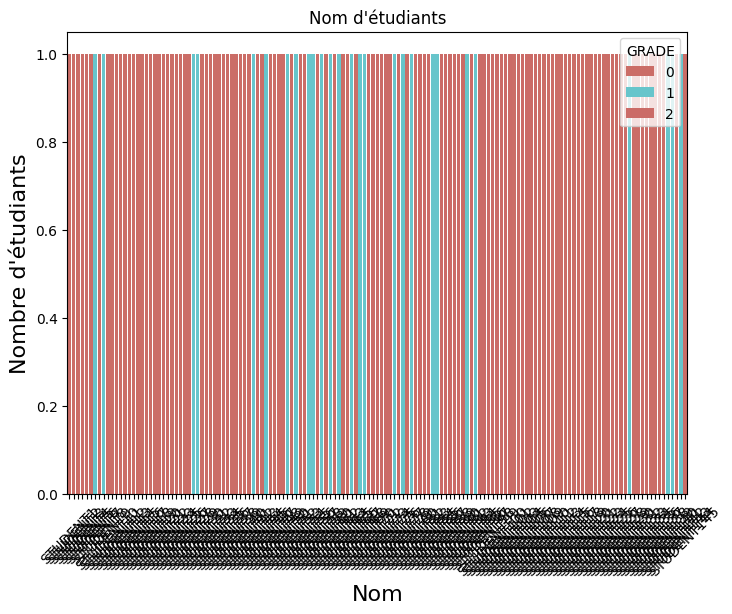

In [ ]:

count_aa = Data[Data['GRADE'] == 1].shape[0]
print(f"Nombre d'etudiant avoir la grade AA: {count_aa}")

#tracer le resultat
sns.countplot(x='STUDENTID',data=Data , palette='hls', hue="GRADE")
plt.xlabel("Nom",fontsize=16)
plt.ylabel("Nombre d'étudiants",fontsize=16)
plt.title('Nom d\'étudiants')
plt.xticks(rotation=45)
plt.show()

### graphique permettant de voir le valeur maquantte

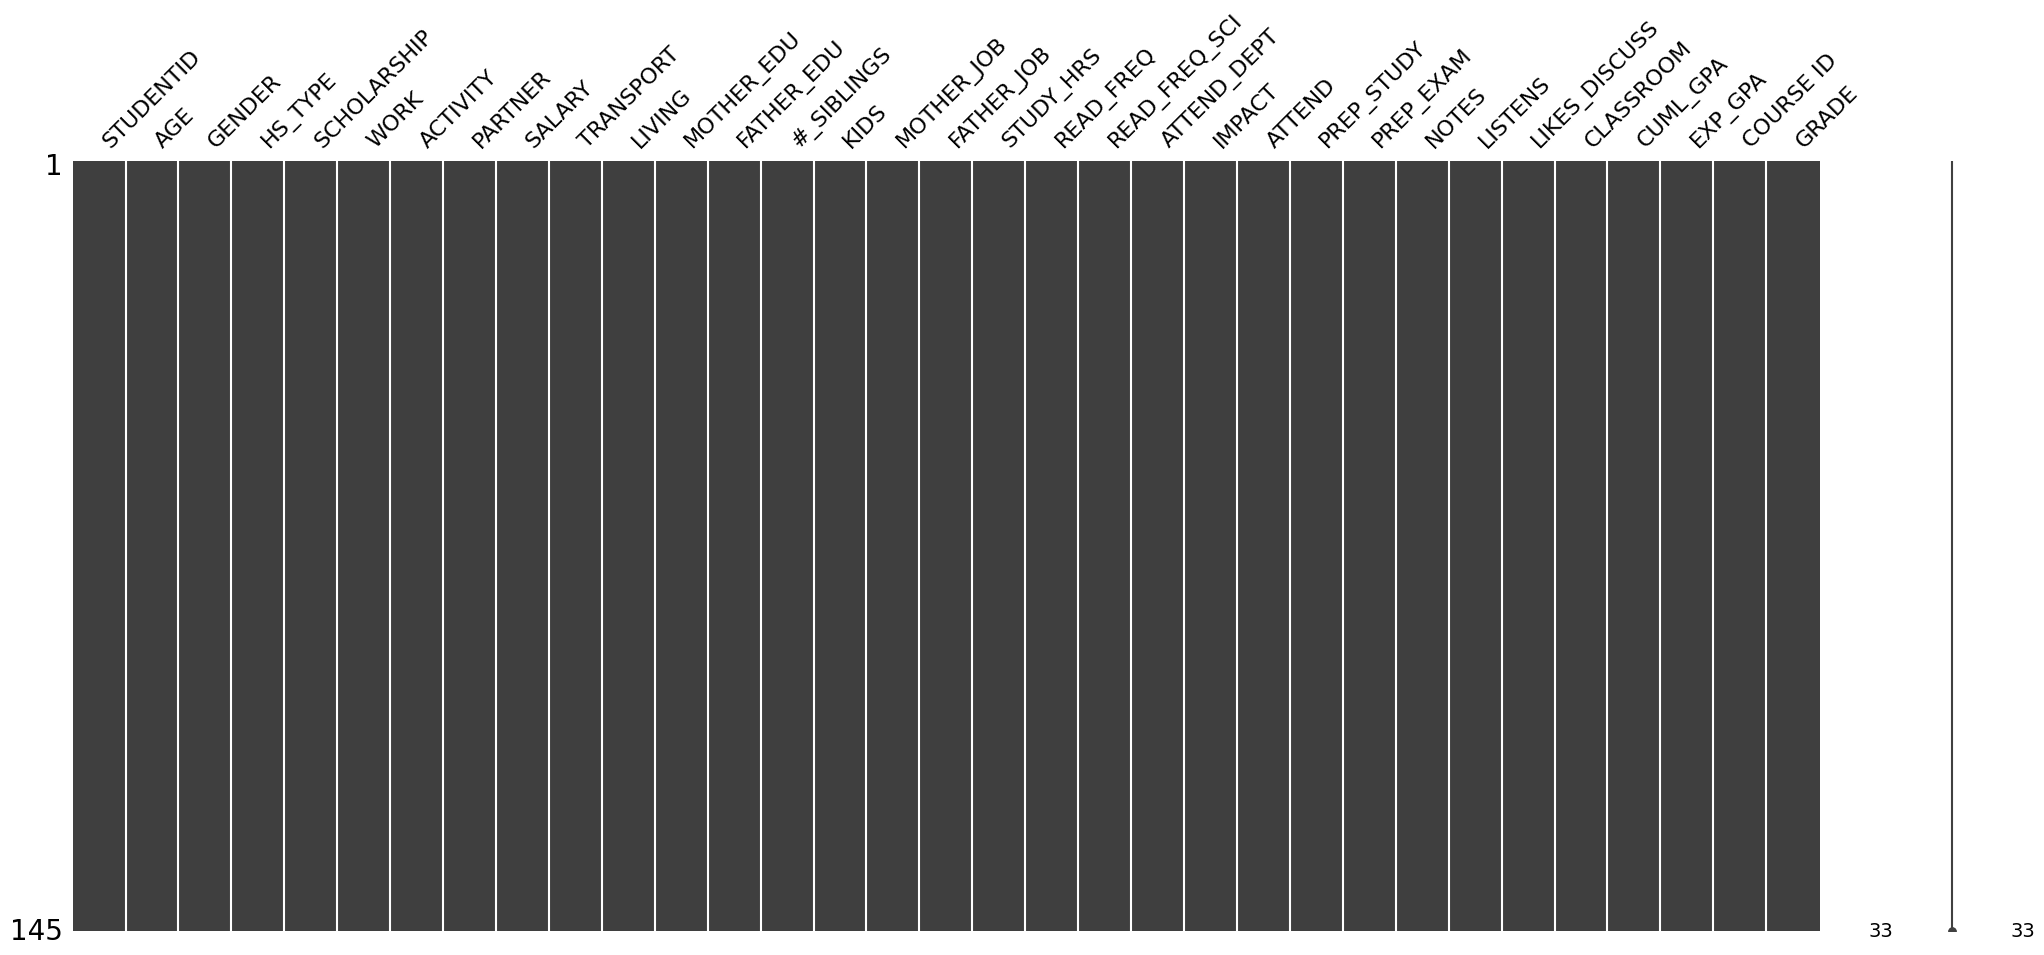

In [ ]:
import missingno as msno
msno.matrix(Data)
plt.show()

In [ ]:
Data

,STUDENTID,AGE,GENDER,HS_TYPE,SCHOLARSHIP,WORK,ACTIVITY,PARTNER,SALARY,TRANSPORT,...,PREP_STUDY,PREP_EXAM,NOTES,LISTENS,LIKES_DISCUSS,CLASSROOM,CUML_GPA,EXP_GPA,COURSE ID,GRADE
0,STUDENT1,0.5,1.0,1.0,0.50,1,1.0,1.0,0.00,0.000000,...,0.0,0.0,1.0,0.5,0.0,0.5,0.00,0.000000,1,0
1,STUDENT2,0.5,1.0,1.0,0.50,1,1.0,1.0,0.00,0.000000,...,0.0,0.0,1.0,0.5,1.0,0.5,0.25,0.666667,1,0
2,STUDENT3,0.5,1.0,0.5,0.50,2,1.0,1.0,0.25,1.000000,...,0.0,0.0,0.5,0.5,0.0,0.0,0.25,0.333333,1,0
3,STUDENT4,0.0,0.0,0.0,0.50,1,1.0,0.0,0.25,0.000000,...,0.0,0.5,1.0,0.5,0.5,0.0,0.50,0.333333,1,0
4,STUDENT5,0.5,1.0,0.0,0.50,2,1.0,0.0,0.50,0.000000,...,0.5,0.0,0.5,0.5,0.5,0.0,0.25,0.333333,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,STUDENT141,0.5,0.0,0.5,0.50,1,0.0,1.0,0.00,0.000000,...,0.0,0.0,0.5,0.0,0.5,0.0,0.50,0.666667,9,1
141,STUDENT142,0.0,0.0,0.5,0.75,2,1.0,1.0,0.00,1.000000,...,0.0,0.0,1.0,0.5,0.5,0.0,1.00,0.666667,9,1
142,STUDENT143,0.0,0.0,0.0,0.75,2,1.0,1.0,0.00,0.000000,...,0.0,0.0,1.0,1.0,0.5,0.0,0.75,0.666667,9,0
143,STUDENT144,0.5,0.0,0.5,0.75,1,0.0,0.0,1.00,0.333333,...,0.5,0.0,0.5,0.0,0.5,0.0,1.00,0.666667,9,1


# **recuperation de la variable dependente et independente**

In [ ]:
# Data Splitting
X = Data.iloc[: , 1:-1].values
y = Data.iloc[: , -1].values

In [ ]:
X

array([[0.5       , 1.        , 1.        , ..., 0.        , 0.        ,
        1.        ],
       [0.5       , 1.        , 1.        , ..., 0.25      , 0.66666667,
        1.        ],
       [0.5       , 1.        , 0.5       , ..., 0.25      , 0.33333333,
        1.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.75      , 0.66666667,
        9.        ],
       [0.5       , 0.        , 0.5       , ..., 1.        , 0.66666667,
        9.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        9.        ]])

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 0, 1, 0, 2, 2, 2, 1, 1, 2,
       2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0])

In [ ]:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
print("Shape of X train:", X_train.shape)
print("Shape of y train:", y_train.shape)
print("Shape of X test:", X_test.shape)
print("Shape of y test:", y_test.shape)

Shape of X train: (116, 31)
Shape of y train: (116,)
Shape of X test: (29, 31)
Shape of y test: (29,)


## **creation du model de prediction**

# 1. LogisticRegression

In [ ]:
# Create a logistic regression model
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
model_LR = LogisticRegression

X, y = make_classification(
    n_samples=1000,
    n_features=32,
    n_informative=3,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    random_state=0,
    shuffle=False,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train the model on the training data
#model_LR.fit(X_train, y_train)
model_LR = LogisticRegression(random_state=0).fit(X_train, y_train)

# Faire des prédictions sur le jeu de test
y_pred_0 = model_LR.predict(X_test)

# Calculer la métrique de performance
print("Accuracy:", accuracy_score(y_test, y_pred_0))
print("MSE:", mean_squared_error(y_test, y_pred_0))

Accuracy: 0.828
MSE: 0.28


In [ ]:
# Make predictions on the test data
#y_pred = model.predict(X_test)

# 2. Multilayer perceptron MLP
### on reduire l'erreur et on augmente l'accuacy

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

# Créer le modèle de MLP Classifier
#model_MLP = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=200)
X, y = make_classification(
    n_samples=1000,
    n_features=32,
    n_informative=3,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    random_state=0,
    shuffle=False,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Entraîner le modèle
model_MLP=MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(15,), random_state=1)
model_MLP.fit(X_train, y_train)

# Faire des prédictions sur le jeu de test
y_pred_1 = model_MLP.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_1))
print("MSE:", mean_squared_error(y_test, y_pred_1))
# Calculer la métrique de performance
#accuracy = model.score(X_test, y_test)
#print(f"Précision du modèle de MLP Classifier : {accuracy:.4f}")

Accuracy: 0.812
MSE: 0.296


# 3 GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Créer le modèle de Gradient Boosting Classifier
#model_GBC = GradientBoostingClassifier(n_estimators=100, max_depth=3)
X, y = make_classification(
    n_samples=1000,
    n_features=32,
    n_informative=3,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    random_state=0,
    shuffle=False,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Entraîner le modèle
model_GBC=GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
    max_depth=1, random_state=0).fit(X_train, y_train)
model_GBC.fit(X_train, y_train)

# Faire des prédictions sur le jeu de test
y_pred_2 = model_GBC.predict(X_test)

# Calculer la métrique de performance
print("Accuracy:", accuracy_score(y_test, y_pred_2))
print("MSE:", mean_squared_error(y_test, y_pred_2))
#accuracy = model.score(X_test, y_test)
#print(f"Précision du modèle de Gradient Boosting Classifier : {accuracy:.4f}")'''

Accuracy: 0.832
MSE: 0.264


In [ ]:
#model.score(X_test, y_test)

In [ ]:
#type(y_test)

In [ ]:
#type(y_pred)

In [ ]:
# Évaluer les performances du modèle
#r2 = r2_score(y_test, y_pred)
#print(f"Coefficient de détermination (R^2): {r2:.2f}")

# 4 DecisionTreeClassifier

In [ ]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=1000,
    n_features=32,
    n_informative=3,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    random_state=0,
    shuffle=False,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Entraîner un modèle d'arbre de décision
model_DTC = DecisionTreeClassifier()
model_DTC.fit(X_train, y_train)

y_pred_3 = model_DTC.predict(X_test)

# Calculer la métrique de performance
print("Accuracy:", accuracy_score(y_test, y_pred_3))
print("MSE:", mean_squared_error(y_test, y_pred_3))


Accuracy: 0.808
MSE: 0.276


# 5. RandomForestClassifier

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=1000,
    n_features=32,
    n_informative=3,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    random_state=0,
    shuffle=False,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

feature_names = Data[Data.columns]
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
y_pred_4 = forest.predict(X_test)
# Calculer la métrique de performance
print("Accuracy:", accuracy_score(y_test, y_pred_4))
print("MSE:", mean_squared_error(y_test, y_pred_4))

Accuracy: 0.868
MSE: 0.204


In [ ]:
y_pred_4

array([2, 2, 2, 2, 0, 2, 0, 1, 1, 2, 1, 1, 2, 0, 0, 0, 1, 1, 1, 2, 2, 1,
       0, 1, 0, 2, 2, 2, 0, 2, 1, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 2, 1, 1, 1, 2, 0, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2, 1, 0,
       2, 0, 2, 1, 1, 2, 2, 2, 2, 2, 2, 0, 1, 1, 2, 2, 0, 0, 1, 2, 0, 1,
       0, 1, 0, 1, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 0, 1,
       1, 2, 2, 0, 1, 0, 2, 2, 2, 0, 1, 2, 1, 2, 2, 1, 1, 1, 2, 2, 0, 1,
       2, 0, 1, 2, 1, 2, 2, 2, 0, 1, 2, 0, 0, 0, 2, 2, 1, 1, 0, 2, 0, 0,
       2, 1, 2, 2, 0, 1, 1, 1, 1, 0, 2, 2, 0, 2, 1, 2, 2, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 2, 1, 0, 2, 0, 2, 2, 2, 2, 0, 2, 1, 1, 0, 2, 1, 1, 2, 2, 0,
       0, 1, 2, 0, 2, 1, 2, 0, 0, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 1, 2, 0,
       2, 1, 0, 2, 0, 1, 2, 1])

# Feature importance

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Obtenir les importances des features
#importances = random_forest_model.feature_importances_
subset = Data[Data.columns]
feature_names = subset.columns
feature_names

Index(['STUDENTID', 'AGE', 'GENDER', 'HS_TYPE', 'SCHOLARSHIP', 'WORK',
       'ACTIVITY', 'PARTNER', 'SALARY', 'TRANSPORT', 'LIVING', 'MOTHER_EDU',
       'FATHER_EDU', '#_SIBLINGS', 'KIDS', 'MOTHER_JOB', 'FATHER_JOB',
       'STUDY_HRS', 'READ_FREQ', 'READ_FREQ_SCI', 'ATTEND_DEPT', 'IMPACT',
       'ATTEND', 'PREP_STUDY', 'PREP_EXAM', 'NOTES', 'LISTENS',
       'LIKES_DISCUSS', 'CLASSROOM', 'CUML_GPA', 'EXP_GPA', 'COURSE ID',
       'GRADE'],
      dtype='object')

In [ ]:


# Créer le modèle de forêt aléatoire
random_forest_model = RandomForestClassifier()

# Entraîner le modèle
random_forest_model.fit(X_train, y_train)

# Obtenir les importances des features
importances = random_forest_model.feature_importances_

importances

array([0.23510113, 0.2873401 , 0.03161136, 0.01342348, 0.01768295,
       0.01295158, 0.01554401, 0.01423011, 0.01494435, 0.01535267,
       0.01506504, 0.0149183 , 0.01709967, 0.02099078, 0.01484297,
       0.01471465, 0.01530992, 0.01737464, 0.01625331, 0.01342737,
       0.01356668, 0.01524035, 0.0145808 , 0.01444845, 0.01313773,
       0.01409836, 0.01645864, 0.01727821, 0.01463119, 0.01744463,
       0.01239344, 0.01854309])

In [ ]:
# Ordonner les importances des features par ordre décroissant
indices = np.argsort(importances)[: :-1]

indices

array([ 1,  0,  2, 13, 31,  4, 29, 17, 27, 12, 26, 18,  6,  9, 16, 21, 10,
        8, 11, 14, 15, 28, 22, 23,  7, 25, 20, 19,  3, 24,  5, 30])

In [ ]:
sorted_feature_names = [feature_names[i] for i in indices]
sorted_feature_names

['AGE',
 'STUDENTID',
 'GENDER',
 '#_SIBLINGS',
 'COURSE ID',
 'SCHOLARSHIP',
 'CUML_GPA',
 'STUDY_HRS',
 'LIKES_DISCUSS',
 'FATHER_EDU',
 'LISTENS',
 'READ_FREQ',
 'ACTIVITY',
 'TRANSPORT',
 'FATHER_JOB',
 'IMPACT',
 'LIVING',
 'SALARY',
 'MOTHER_EDU',
 'KIDS',
 'MOTHER_JOB',
 'CLASSROOM',
 'ATTEND',
 'PREP_STUDY',
 'PARTNER',
 'NOTES',
 'ATTEND_DEPT',
 'READ_FREQ_SCI',
 'HS_TYPE',
 'PREP_EXAM',
 'WORK',
 'EXP_GPA']

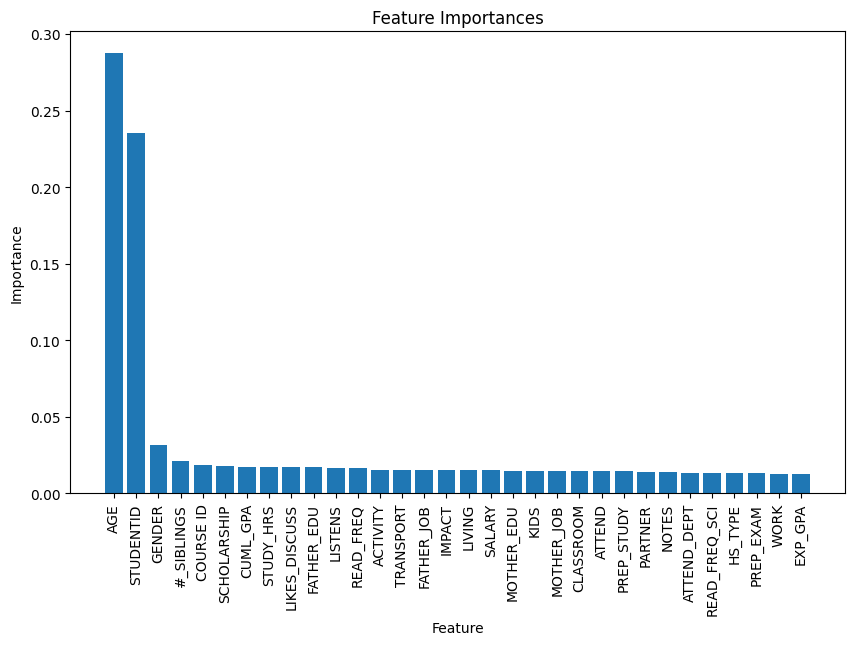

In [ ]:
# Tracer les importances des features
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), sorted_feature_names, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

In [ ]:
estudiants_echoué=Data[Data['GRADE']==0]
estudiants_echoué

,STUDENTID,AGE,GENDER,HS_TYPE,SCHOLARSHIP,WORK,ACTIVITY,PARTNER,SALARY,TRANSPORT,...,PREP_STUDY,PREP_EXAM,NOTES,LISTENS,LIKES_DISCUSS,CLASSROOM,CUML_GPA,EXP_GPA,COURSE ID,GRADE
0,STUDENT1,0.5,1.0,1.0,0.50,1,1.0,1.0,0.00,0.000000,...,0.0,0.0,1.0,0.5,0.0,0.5,0.00,0.000000,1,0
1,STUDENT2,0.5,1.0,1.0,0.50,1,1.0,1.0,0.00,0.000000,...,0.0,0.0,1.0,0.5,1.0,0.5,0.25,0.666667,1,0
2,STUDENT3,0.5,1.0,0.5,0.50,2,1.0,1.0,0.25,1.000000,...,0.0,0.0,0.5,0.5,0.0,0.0,0.25,0.333333,1,0
3,STUDENT4,0.0,0.0,0.0,0.50,1,1.0,0.0,0.25,0.000000,...,0.0,0.5,1.0,0.5,0.5,0.0,0.50,0.333333,1,0
4,STUDENT5,0.5,1.0,0.0,0.50,2,1.0,0.0,0.50,0.000000,...,0.5,0.0,0.5,0.5,0.5,0.0,0.25,0.333333,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,STUDENT138,0.0,0.0,0.0,1.00,2,0.0,1.0,0.00,0.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.25,1.000000,9,0
138,STUDENT139,0.0,0.0,0.5,0.75,1,0.0,0.0,1.00,0.333333,...,0.5,0.0,1.0,0.5,1.0,0.0,0.00,0.666667,9,0
139,STUDENT140,0.0,0.0,0.5,0.75,1,1.0,0.0,0.25,0.333333,...,0.5,0.0,0.5,1.0,0.5,0.0,0.00,0.333333,9,0
142,STUDENT143,0.0,0.0,0.0,0.75,2,1.0,1.0,0.00,0.000000,...,0.0,0.0,1.0,1.0,0.5,0.0,0.75,0.666667,9,0


In [ ]:
estudiants_reussi_sans_distinction=Data[Data['GRADE']==1]
estudiants_reussi_sans_distinction

,STUDENTID,AGE,GENDER,HS_TYPE,SCHOLARSHIP,WORK,ACTIVITY,PARTNER,SALARY,TRANSPORT,...,PREP_STUDY,PREP_EXAM,NOTES,LISTENS,LIKES_DISCUSS,CLASSROOM,CUML_GPA,EXP_GPA,COURSE ID,GRADE
6,STUDENT7,0.0,1.0,0.5,0.75,2,1.0,1.0,0.00,0.000000,...,0.0,0.0,1.0,1.0,1.0,1.0,0.75,1.000000,1,1
8,STUDENT9,0.5,0.0,1.0,0.50,2,0.0,0.0,0.00,0.000000,...,0.0,0.0,1.0,0.5,0.5,0.5,0.75,0.666667,1,1
29,STUDENT30,0.5,1.0,1.0,0.75,2,1.0,1.0,0.00,1.000000,...,0.0,0.0,1.0,0.5,0.5,0.5,0.75,0.666667,1,1
30,STUDENT31,0.5,1.0,0.5,1.00,1,0.0,0.0,0.00,0.000000,...,0.5,0.0,0.5,1.0,1.0,1.0,1.00,1.000000,1,1
43,STUDENT44,0.0,1.0,0.5,0.50,2,1.0,0.0,0.00,0.000000,...,0.0,0.0,1.0,0.0,1.0,1.0,0.50,0.333333,1,1
46,STUDENT47,0.5,1.0,0.5,0.50,2,1.0,0.0,0.00,0.000000,...,0.0,0.0,0.5,0.5,1.0,0.0,0.75,0.333333,1,1
51,STUDENT52,0.5,0.0,1.0,0.50,1,0.0,1.0,0.00,0.000000,...,0.0,0.0,0.5,1.0,1.0,0.0,0.50,0.666667,1,1
53,STUDENT54,0.5,0.0,0.5,0.50,2,0.0,1.0,0.25,0.000000,...,0.0,0.0,0.5,0.5,0.5,0.5,0.50,0.333333,1,1
56,STUDENT57,0.5,1.0,0.5,0.50,2,0.0,1.0,0.00,0.000000,...,0.0,0.5,1.0,0.5,1.0,1.0,1.00,1.000000,1,1
57,STUDENT58,0.5,1.0,0.5,0.50,1,0.0,1.0,0.00,0.000000,...,0.0,0.0,1.0,0.5,1.0,0.0,1.00,1.000000,1,1


In [ ]:
estudiants_reussi_avec_distinction=Data[Data['GRADE']==2]
estudiants_reussi_avec_distinction

,STUDENTID,AGE,GENDER,HS_TYPE,SCHOLARSHIP,WORK,ACTIVITY,PARTNER,SALARY,TRANSPORT,...,PREP_STUDY,PREP_EXAM,NOTES,LISTENS,LIKES_DISCUSS,CLASSROOM,CUML_GPA,EXP_GPA,COURSE ID,GRADE
70,STUDENT71,0.0,1.0,0.5,0.75,2,0.0,0.0,0.00,0.000000,...,0.0,0.0,0.5,0.5,1.0,0.0,1.00,1.000000,3,2
71,STUDENT72,0.0,0.0,1.0,0.75,2,1.0,1.0,0.00,0.000000,...,0.0,0.0,0.5,1.0,1.0,1.0,0.25,0.333333,3,2
72,STUDENT73,0.0,1.0,0.5,0.50,2,0.0,0.0,0.00,0.000000,...,0.0,0.0,0.5,0.5,1.0,0.5,0.50,0.666667,3,2
73,STUDENT74,0.5,1.0,0.5,0.75,2,1.0,1.0,0.00,0.000000,...,0.0,0.5,1.0,0.5,1.0,0.0,1.00,0.666667,3,2
74,STUDENT75,0.0,1.0,0.5,0.75,2,1.0,1.0,0.00,0.000000,...,0.5,0.0,1.0,0.5,1.0,0.5,0.50,0.666667,3,2
75,STUDENT76,0.0,1.0,0.5,0.75,2,0.0,1.0,0.00,0.000000,...,0.0,0.0,0.5,0.5,0.5,0.5,0.75,0.000000,3,2
77,STUDENT78,0.0,1.0,0.0,0.25,2,1.0,0.0,0.25,0.333333,...,1.0,0.0,0.5,0.5,0.5,0.5,0.00,0.000000,4,2
82,STUDENT83,0.5,1.0,0.5,0.75,1,1.0,0.0,0.25,0.000000,...,0.0,0.0,1.0,1.0,0.5,1.0,0.75,0.666667,5,2
83,STUDENT84,0.5,1.0,1.0,0.50,2,1.0,1.0,0.50,0.000000,...,1.0,0.0,1.0,0.5,1.0,1.0,0.00,0.333333,5,2
84,STUDENT85,1.0,1.0,1.0,0.50,1,1.0,0.0,0.50,0.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.00,1.000000,5,2
